## Collect Dynamic Forcing Data for location

Inland data: USGS active streamgages, STREAM-geo/NLDI river geometry, reservoir conditions, direct AORC SST rainfall members, and NWM soil-moisture context.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from study_location import bootstrap
session = bootstrap()
location_root = session.location_root
repo_root = session.repo_root

# plan reruns, reuse reviewed data, and audit readiness.
import collect_sources.workflow as collect
from collect_sources.nwm import soil_moisture_csv_has_variables
from collect_sources.usgs_streamgages import discover_active_streamgage_candidates, write_reviewed_streamgage_network


runtime = collect.load_runtime(location_root)
config = runtime.runtime_config
paths = runtime.runtime_paths

display(collect.summary(config, paths))
display(collect.source_records(runtime))


location                                                       austin
sources_root        /home/grahamhults/projects/Flood-RM/locations/...
collection_start                                           1979-02-01
collection_end                                             2022-12-31
Name: source_collection, dtype: str

,record,configured,location_root_syntax,exists
0,active USGS streamgage candidates,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,True
1,reviewed streamgage network,data/sources/usgs_streamgages/streamgage_netwo...,"location_root / ""data/sources/usgs_streamgages...",True
2,reviewed discharge records,data/sources/usgs_streamgages/streamflow_recor...,"location_root / ""data/sources/usgs_streamgages...",True
3,AORC rainfall members,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,True
4,NWM soil-moisture members,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,True
5,STREAM-geo river geometry cache,data/sources/national_hydrography/stream_geo.p...,"location_root / ""data/sources/national_hydrogr...",True
6,NLDI STREAM-geo COMID join cache,data/sources/national_hydrography/nldi_stream_...,"location_root / ""data/sources/national_hydrogr...",False
7,NHDPlusV2 flowlines for STREAM-geo join,data/sources/national_hydrography/nhdplus_v2_f...,"location_root / ""data/sources/national_hydrogr...",False
8,NHDPlus river geometry,data/sources/national_hydrography/nhdplus_hr_r...,"location_root / ""data/sources/national_hydrogr...",True
9,NHDPlus catchments,data/sources/national_hydrography/nhdplus_hr_c...,"location_root / ""data/sources/national_hydrogr...",True


### Rerun


In [ ]:
rerun = False
source_skip_existing = not rerun


### Source Collection Plan

In [3]:
plan = collect.plan(config, paths)
plan_table = collect.plan_table(
    plan,
    paths,
    rerun=rerun,
)
display(plan_table)


,source,start,end,will_reuse_existing,action
0,usgs_streamgages,1979-02-01,2022-12-31,True,reuse complete artifact
1,lcra_hydromet,1979-02-01,2022-12-31,False,collect or repair
2,national_hydrography,1979-02-01,2022-12-31,True,reuse complete artifact
3,nwm,1979-02-01,2022-12-31,True,reuse complete artifact
4,aorc_sst,1979-02-01,2022-12-31,True,reuse complete artifact


### USGS Active Streamgage Discovery

In [4]:
discovery_summary, records_summary = collect.discover_gages(runtime)
display(discovery_summary)
display(records_summary)
display(collect.gage_readiness(runtime))


provider                                                           USGS NWIS
site_service_url                   https://waterservices.usgs.gov/nwis/site/
parameter_cd                                                           00060
site_status                                                           active
data_types                                                              None
bbox                                -98.370226,30.023614,-97.587078,30.82078
search_geometry             data/static/aoi/wflow_nhdplus_watersheds.geojson
hydrologic_buffer_km                                                    None
active_records_only                                                     True
candidate_output           /home/grahamhults/projects/Flood-RM/locations/...
candidate_output_exists                                                 True
Name: usgs_active_streamgage_discovery, dtype: object

records_service                                                           dv
records_output             data/sources/usgs_streamgages/streamflow_recor...
records_output_exists                                                   True
request_timeout_seconds                                                   60
stat_cd                                                                00003
Name: usgs_reviewed_discharge_records, dtype: object

,artifact,path,exists,ready
0,streamgage candidates,/home/grahamhults/projects/Flood-RM/locations/...,True,True
9,soil moisture,/home/grahamhults/projects/Flood-RM/locations/...,True,True


### Stochastic Storm Transposition Region

The SST region is defined in `config.yaml`

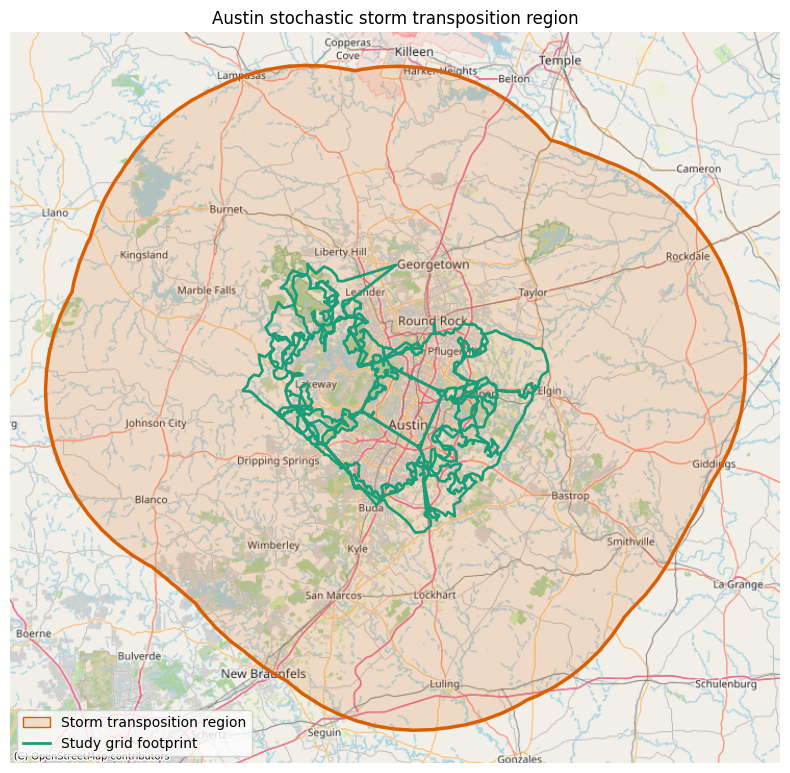

In [5]:
# Plot the configured AORC SST transposition region before pulling rainfall members.
fig, ax = collect.plot_sst_region(config, paths)

### STREAM-geo/NLDI River Geometry

STREAM-geo width/depth estimates are cached for native Wflow river-geometry enrichment

In [ ]:
display(collect.stream_sources(config, paths))

source                                                           STREAM-geo/NLDI
stream_geo_table               data/sources/national_hydrography/stream_geo.p...
stream_geo_table_exists                                                     True
nldi_lookup_cache              data/sources/national_hydrography/nldi_stream_...
nldi_lookup_cache_exists                                                   False
nhdplus_v2_flowlines           data/sources/national_hydrography/nhdplus_v2_f...
nhdplus_v2_flowlines_exists                                                False
stream_geo_join_method                                        attribute_transfer
nldi_role                                                COMID lookup provenance
manifest                       /home/grahamhults/projects/Flood-RM/locations/...
manifest_exists                                                             True
Name: stream_geo_nldi, dtype: object

### Reservoir Condition Inputs -- **location dependent**. 

In [ ]:
display(collect.reservoir_sources(config, paths))

enabled                                                           True
provider                                     twdb_water_data_for_texas
period_suffix                                                   -1year
statistic                                                       median
reservoir_slugs         austin, lyndon-b-johnson, marble-falls, travis
summary_csv          /home/grahamhults/projects/Flood-RM/locations/...
summary_exists                                                    True
provenance_json      /home/grahamhults/projects/Flood-RM/locations/...
provenance_exists                                                 True
Name: reservoir_conditions, dtype: object

### Stochastic Storm Transposition Process

Scans the transposition region, ranks rolling storm windows, and writes the rainfall-member table for precipitation pairing with streamflow and antecedent soil-moisture states.

**chosen parameters by academic references**

In [ ]:
# --- AORC SST collection parameters (edit to retune, then run Run Collection below) ---
# Threshold-driven POT: keep every INDEPENDENT storm whose 72h footprint-mean depth
# exceeds the threshold, so the rainfall-member count is data-driven
# Set the threshold from the rainfall POT diagnostics; raise it for fewer, heavier members.
min_precip_threshold = 40.0   # mm over the 72h storm window (footprint mean)
decluster_hours = 72          # minimum spacing between independent storms --
storm_duration_hours = 72     # SST rainfall accumulation window
check_every_n_hours = 6       # transposition scan stride
defer_event_windows = True    # write AORC event-window NetCDFs, including Wflow meteo, in the separate cell below

display(collect.aorc_sst_params(
    config,
    paths,
    min_precip_threshold=min_precip_threshold,
    decluster_hours=decluster_hours,
    storm_duration_hours=storm_duration_hours,
    check_every_n_hours=check_every_n_hours,
    defer_event_windows=defer_event_windows,
))


source                                                       direct_aorc_sst
transposition_region_id                        austin-inland-review-required
transposition_region       data/sources/aorc_sst/transposition_regions/tr...
start_date                                                        1979-02-01
end_date                                                          2022-12-31
selection                  threshold-driven POT (every independent storm ...
min_precip_threshold_mm                                                 40.0
storm_duration_hours                                                      72
decluster_hours                                                           72
check_every_n_hours                                                        6
top_n_events_safety_cap                                                 None
defer_event_windows                                                     True
event_meteo_enabled                                                     True

### NWM Soil-Moisture Context

Selected NWM LDAS soil-moisture cells are retained for antecedent-condition pairing.

In [10]:
soil_variables = config["collection"]["nwm"]["soil_moisture"]["variables"]
soil_moisture_path = runtime.resolve_location_path(config["event_catalog"]["forcing_members"]["soil_moisture"])
soil_moisture_ready = soil_moisture_csv_has_variables(soil_moisture_path, soil_variables)
display(collect.soil_sources(config, paths))
display(pd.Series({"soil_moisture_path": soil_moisture_path, "soil_moisture_ready": soil_moisture_ready}, name="nwm_soil_moisture_readiness"))

version                                                                               None
streamflow_available                                                                  None
streamflow_reason                                                                     None
soil_moisture_points                                                                     0
soil_moisture_variables                                                                 []
soil_moisture_zarr                                                                    None
soil_moisture_csv                        /home/grahamhults/projects/Flood-RM/locations/...
soil_moisture_exists                                                                  True
soil_moisture_has_requested_variables                                                 True
Name: nwm_soil_moisture, dtype: object

soil_moisture_path     /home/grahamhults/projects/Flood-RM/locations/...
soil_moisture_ready                                                 True
Name: nwm_soil_moisture_readiness, dtype: object

### Run Collection

In [ ]:
rerun = False
source_skip_existing = not rerun


### AORC SST Event Windows

Materialize per-storm AORC event-window NetCDFs with paired precipitation and Wflow meteo after the rainfall member table is current.


In [ ]:
# Materialize per-storm AORC event-window NetCDFs with paired precip + Wflow meteo.
aorc_event_window_result = collect.collect_aorc_sst_event_windows(
    config,
    paths,
    plan,
    skip_existing=source_skip_existing,
)
display(aorc_event_window_result)

aorc_event_window_readiness = collect.aorc_sst_event_window_readiness(config, paths, plan)
display(aorc_event_window_readiness)
if aorc_event_window_readiness["status"] != "ready":
    raise RuntimeError(
        "AORC event windows are not ready for paired Wflow/SFINCS forcing: "
        f"{aorc_event_window_readiness.to_dict()}"
    )


### Reservoir Collection Review

In [13]:
reservoir_conditions = collect.reservoir_condition_table(config, paths)
display(reservoir_conditions)


,waterbody_name,twdb_slug,condition_status,condition_statistic,condition_period_start,condition_period_end,Depth_avg,reservoir_storage_acft,surface_area_acres,percent_full,condition_reason
0,Lake Travis,travis,matched,median,2025-06-23,2026-06-23,16.940778,888132.5,15979.36,79.35,NaN
1,Lake Lyndon B Johnson,lyndon-b-johnson,matched,median,2025-06-23,2026-06-23,6.177359,129821.0,6405.56,98.40,NaN
2,Lake Austin,austin,matched,median,2025-06-23,2026-06-23,4.667799,23690.0,1546.92,96.30,NaN
3,NaN,NaN,missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no configured TWDB slug
4,Lake Marble Falls,marble-falls,matched,median,2025-06-23,2026-06-23,3.658817,7215.0,601.05,95.00,NaN
5,Lady Bird Lake,NaN,missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no configured TWDB slug


### Review Collected Streamgages


In [ ]:
write_reviewed_streamgage_network_file = True
reviewed_network_decisions = collect.build_reviewed_streamgage_decisions(config, paths)
reviewed_streamgage_decision_table = pd.DataFrame(reviewed_network_decisions)
if write_reviewed_streamgage_network_file:
    reviewed_network_result = write_reviewed_streamgage_network(config, paths, reviewed_network_decisions)
else:
    reviewed_network_result = {
        "status": "review_pending",
        "reviewed_network_geojson": str(runtime.reviewed_network_path),
        "accepted_count": int(reviewed_streamgage_decision_table["review_status"].str.startswith("accepted").sum()),
        "reason": "Review candidate gages, then set write_reviewed_streamgage_network_file=True.",
    }

fig, artifact_summary, gage_domain_summary = collect.plot_usgs_streamgage_network(runtime)
reviewed_records_result = collect.collect_gage_records(runtime, skip_existing=source_skip_existing)

display(reviewed_streamgage_decision_table)
display(pd.Series(reviewed_network_result, name="reviewed_streamgage_network"))
display(pd.Series(reviewed_records_result, name="usgs_reviewed_discharge_records"))
display(artifact_summary)
display(gage_domain_summary)


## Collected Data Overview

In [15]:
display(collect.overview())

,driver,source,event_use
0,streamflow,USGS active streamgages,POT frequency basis and Wflow validation
1,rainfall,AORC SST,direct rainfall and Wflow precipitation forcing
2,soil_moisture,NWM retrospective,antecedent state pairing


### SST Transposition Targets

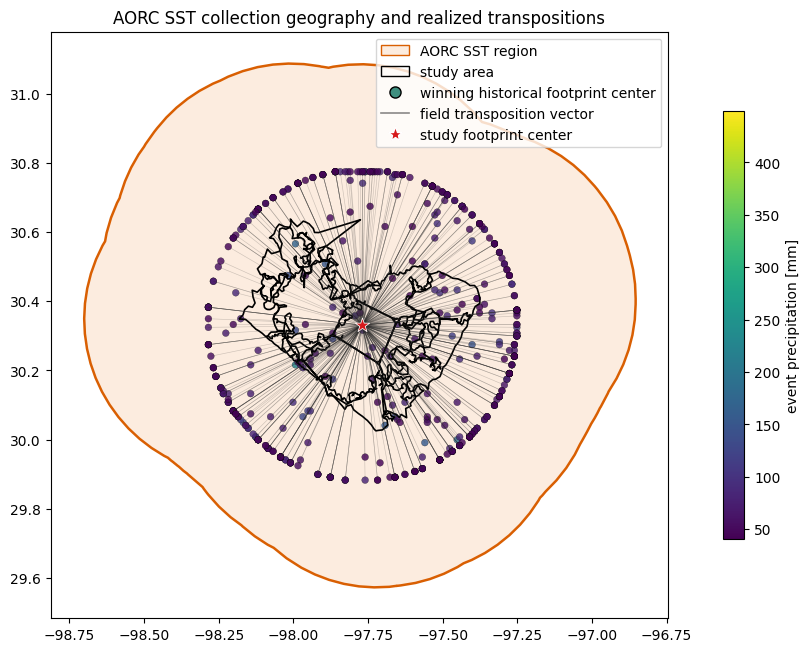

In [16]:
# Plot the SST region, study area, and rainfall transposition targets.
fig, ax = collect.plot_collected_sst_geography(config, paths)

### NWM Soil Moisture

requested_variables                                                   []
available_variables                                             [SOIL_M]
missing_variables                                                     []
csv                    /home/grahamhults/projects/Flood-RM/locations/...
Name: nwm_soil_moisture_status, dtype: object

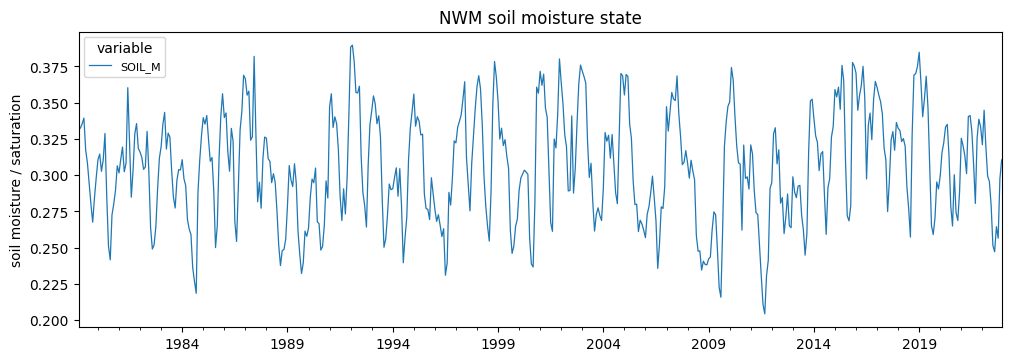

In [18]:
# Plot monthly mean NWM soil moisture variables when available.
fig, status = collect.plot_nwm_soil_moisture(config, paths)
display(status)

### AORC SST Rainfall

Rainfall members are shown as selected-event magnitude and distribution summaries.


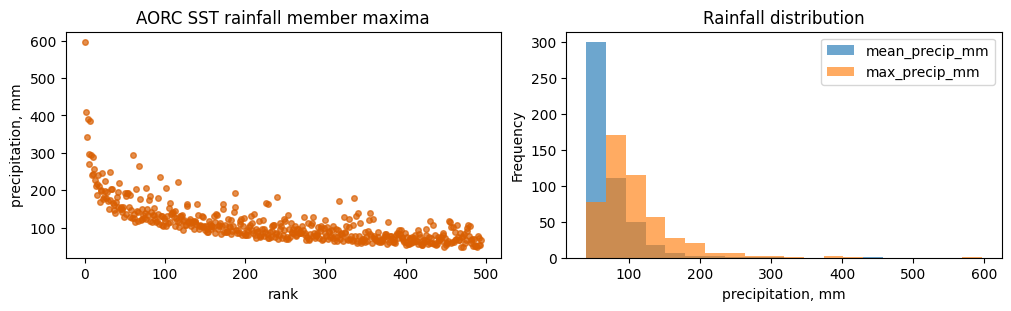

In [19]:
# Plot compact AORC SST rainfall member summaries.
fig = collect.plot_aorc_sst_rainfall(paths)